In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os
import pathlib
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
root_path = "/Users/felipepesantez/Documents/development/datasets/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

In [3]:
os.listdir(root_path)

['fix_images.py', 'test', 'train', 'val']

In [4]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [5]:
num_fractured_bone_images = len(os.listdir(root_path + "/train/fractured"))
num_not_fractured_bone_images = len(os.listdir(root_path + "/train/not fractured"))
num_fractured_bone_images, num_not_fractured_bone_images

(4602, 4639)

In [6]:
#get class names
data_dir = pathlib.Path(root_path + "/train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['fractured' 'not fractured']


In [7]:
def random_img(dirpath, target_class):
    directory = dirpath + "/" + target_class
    random_img = random.sample(os.listdir(directory), 1)

    img = mpimg.imread(directory + "/" + random_img[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")

    print(f"Image shape: {img.shape}")

    return img

Image shape: (224, 224, 3)


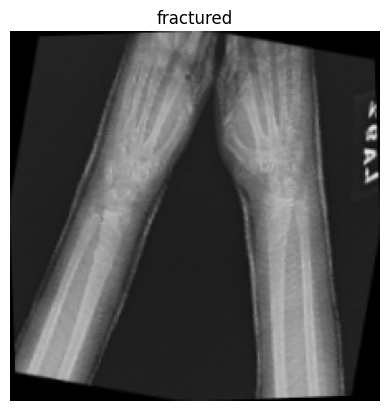

In [8]:
img = random_img(root_path + "/train", class_names[0])

In [9]:
#model

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_dir = root_path + "/" + "train"
test_dir = root_path + "/" + "test"
val_dir = root_path + "/" + "val"

In [12]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary")
test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary")
val_data = val_datagen.flow_from_directory(val_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary")

Found 9241 images belonging to 2 classes.
Found 505 images belonging to 2 classes.
Found 824 images belonging to 2 classes.


In [13]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation='relu',
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding='valid'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(loss='binary_crossentropy',
                       optimizer=tf.keras.optimizers.legacy.Adam(),
                       metrics=["accuracy"])

baseline_model_loss = baseline_model.fit(train_data,
                                         epochs=5,
                                         steps_per_epoch=len(train_data),
                                         validation_data=val_data,
                                         validation_steps=len(val_data))

2024-06-04 09:18:34.184183: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2024-06-04 09:18:34.184215: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2024-06-04 09:18:34.184224: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 24.00 GB
2024-06-04 09:18:34.184304: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-06-04 09:18:34.184548: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/5


2024-06-04 09:18:34.737389: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


289/289 [==============================] - ETA: 0s - loss: 0.3770 - accuracy: 0.8321

/Users/felipepesantez/anaconda3/envs/tflow/lib/python3.10/site-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 [==============================] - 19s 64ms/step - loss: 0.3770 - accuracy: 0.8321 - val_loss: 0.2869 - val_accuracy: 0.8993
Epoch 2/5
289/289 [==============================] - 17s 58ms/step - loss: 0.1215 - accuracy: 0.9603 - val_loss: 0.2324 - val_accuracy: 0.9357
Epoch 3/5
289/289 [==============================] - 17s 59ms/step - loss: 0.0561 - accuracy: 0.9844 - val_loss: 0.2574 - val_accuracy: 0.9527
Epoch 4/5
289/289 [==============================] - 17s 59ms/step - loss: 0.0299 - accuracy: 0.9912 - val_loss: 0.2745 - val_accuracy: 0.9515
Epoch 5/5
289/289 [==============================] - 17s 59ms/step - loss: 0.0164 - accuracy: 0.9943 - val_loss: 0.2416 - val_accuracy: 0.9684


In [14]:
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 10)      280       
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 10)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 108, 10)      910       
                                                                 
 conv2d_3 (Conv2D)           (None, 106, 106, 10)      910       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 53, 53, 10)        0         
 g2D)                                                   

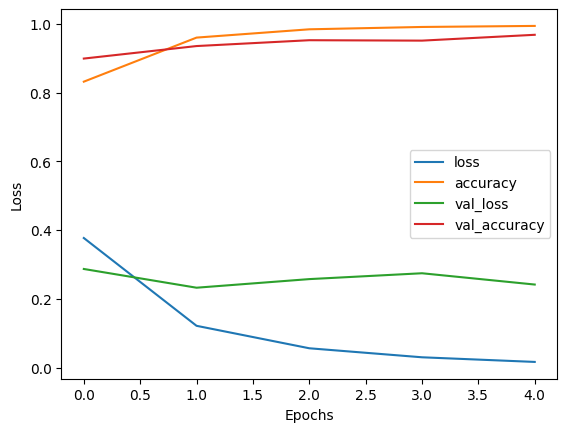

In [15]:
pd.DataFrame(baseline_model_loss.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [17]:
train_datagen_ag = ImageDataGenerator(rescale=1./255,
                                      rotation_range=20,
                                      shear_range=0.2,
                                      zoom_range=0.2,
                                      horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)                                      
val_datagen = ImageDataGenerator(rescale=1./255)                                      

In [18]:
train_data_ag = train_datagen_ag.flow_from_directory(train_dir,
                                                     batch_size=32,
                                                     target_size=(224,224),
                                                     class_mode="binary",
                                                     shuffle=True)
test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(224,224),
                                             class_mode="binary")                                                     
val_data = test_datagen.flow_from_directory(val_dir,
                                             batch_size=32,
                                             target_size=(224,224),
                                             class_mode="binary")                                                     

Found 9241 images belonging to 2 classes.
Found 505 images belonging to 2 classes.
Found 824 images belonging to 2 classes.


In [19]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(10,3,activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

model_1_loss = model_1.fit(train_data_ag,
                           epochs=5,
                           steps_per_epoch=len(train_data_ag),
                           validation_data=val_data,
                           validation_steps=len(val_data))

Epoch 1/5


2024-06-04 09:32:24.324517: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


289/289 [==============================] - ETA: 0s - loss: 0.5859 - accuracy: 0.6735

/Users/felipepesantez/anaconda3/envs/tflow/lib/python3.10/site-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 [==============================] - 55s 190ms/step - loss: 0.5859 - accuracy: 0.6735 - val_loss: 0.4951 - val_accuracy: 0.7937
Epoch 2/5
289/289 [==============================] - 53s 185ms/step - loss: 0.4780 - accuracy: 0.7694 - val_loss: 0.4146 - val_accuracy: 0.8289
Epoch 3/5
289/289 [==============================] - 53s 185ms/step - loss: 0.4160 - accuracy: 0.8112 - val_loss: 0.3927 - val_accuracy: 0.8410
Epoch 4/5
289/289 [==============================] - 54s 185ms/step - loss: 0.3628 - accuracy: 0.8459 - val_loss: 0.3578 - val_accuracy: 0.8507
Epoch 5/5
289/289 [==============================] - 53s 185ms/step - loss: 0.3291 - accuracy: 0.8616 - val_loss: 0.3566 - val_accuracy: 0.8665


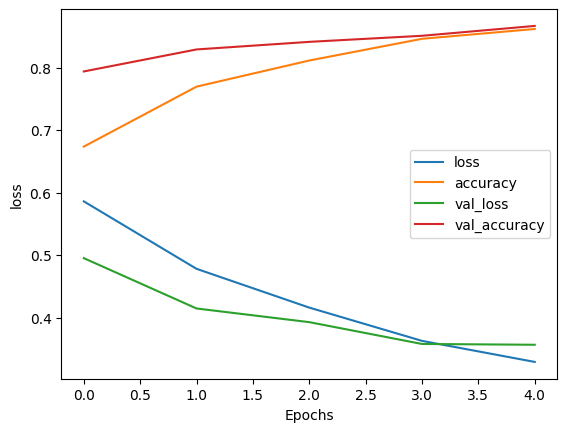

In [20]:
pd.DataFrame(model_1_loss.history).plot()
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.show()